In [1]:
# SIMPLE 2RING HD MODEL 
# This script simulates a simple two-ring head-direction network.
# One ring represents HD cells, and the other ring represents inhibitory cells.

import numpy as np
import matplotlib.pyplot as plt
import random
import time
from IPython import display

random.seed(10)

In [2]:
# ------------------------------------------------------------
# #1. Define network size and Gaussian parameters
# ------------------------------------------------------------
NHD  = 101 # Number of head-direction neurons
NIN  = NHD # Number of inhibitory neurons.
amp  = 1                               
sig  = 1.1                              
sig  = NHD*sig/(2*np.pi)                  
sig2 = 1.1                             
sig2 = NHD*sig2/(2*np.pi)                   
offset = 36;  # 130 for 360neurons, 36 for 100 neurons % how far the inhibition is offset


In [3]:
# ------------------------------------------------------------
# 2. Initialize connection weight matrices
# ------------------------------------------------------------

# Connection weights from HD cells to inhibitory cells
HD2INHwts = np.zeros((NHD, NHD))

# Connection weights from inhibitory cells to HD cells,
# shifted in the clockwise direction
INH2HDwtsCW = np.zeros((NHD, NHD))

# Connection weights from inhibitory cells to HD cells,
# shifted in the counterclockwise direction
INH2HDwtsCCW = np.zeros((NHD, NHD))


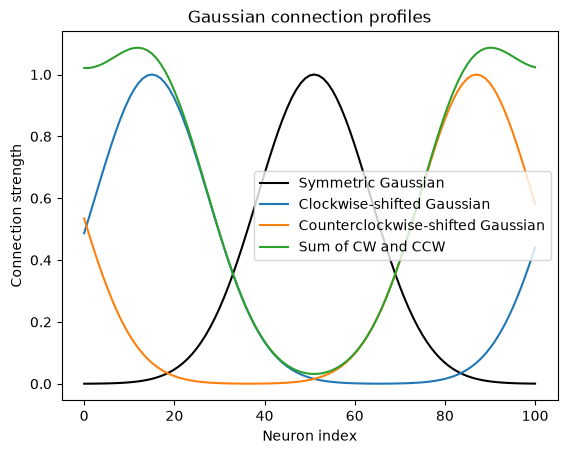

In [4]:
# ------------------------------------------------------------
# 3. Create Gaussian connection profiles
# ------------------------------------------------------------
x  = np.arange(NHD)
x0 = np.floor(NHD/2)+1                                

Gaussian    = amp*np.exp(-((x-x0)/sig)**2)
Gaussian2   = amp*np.exp(-((x-x0)/sig2)**2)   
GaussianCW  = np.roll(Gaussian.T,-offset)     
GaussianCCW = np.roll(Gaussian.T,offset)



plt.figure(123)

plt.plot(Gaussian2, 'k', label="Symmetric Gaussian")
plt.plot(GaussianCW, label="Clockwise-shifted Gaussian")
plt.plot(GaussianCCW, label="Counterclockwise-shifted Gaussian")
plt.plot(GaussianCW + GaussianCCW, label="Sum of CW and CCW")

plt.title("Gaussian connection profiles")
plt.xlabel("Neuron index")
plt.ylabel("Connection strength")
plt.legend()
plt.show()

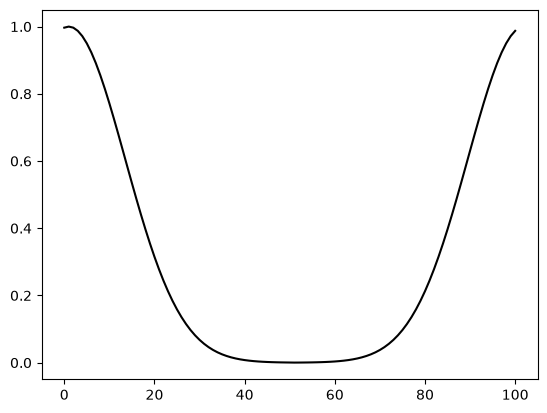

In [5]:

# ------------------------------------------------------------
# 4. Shift Gaussian profiles to align them with the ring structure
# ------------------------------------------------------------

shiftby = np.floor(NHD/2)
shiftby = shiftby.astype(int)
Gaussian2 = np.roll(Gaussian2,-shiftby)
plt.figure(111)
plt.plot(Gaussian2, 'k', label="Shifted Symmetric Gaussian")
GaussianCW = np.roll(GaussianCW,-shiftby)
GaussianCCW = np.roll(GaussianCCW,-shiftby)

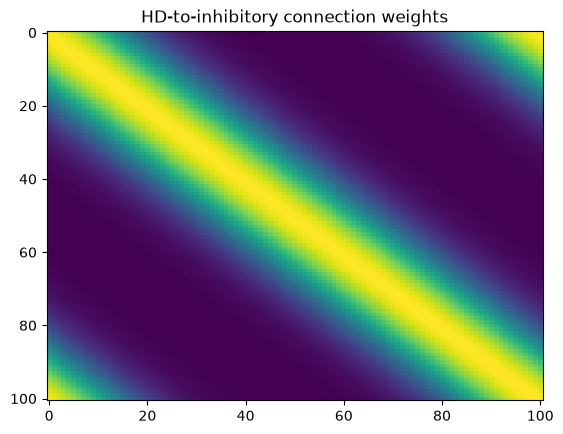

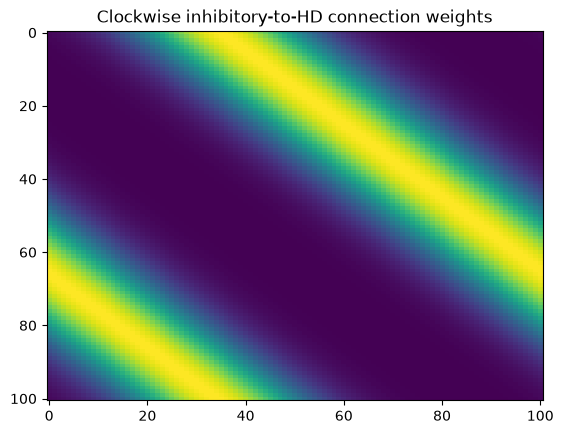

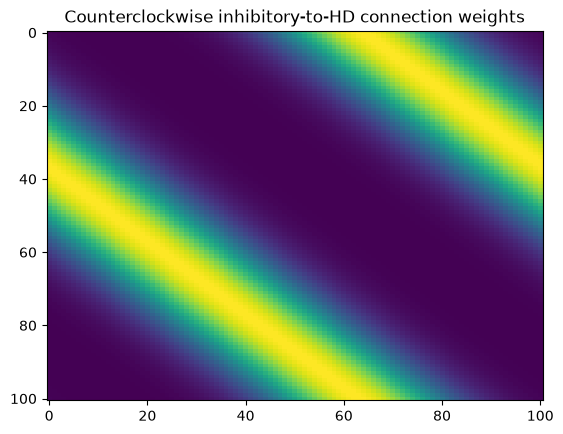

In [6]:
# ------------------------------------------------------------
# 5. Build full connection matrices
# ------------------------------------------------------------

for x0 in range(NHD):                         

    HD2INHwts[:,x0] = Gaussian2
    Gaussian2 = np.roll(Gaussian2,1)
    
    INH2HDwtsCW[:,x0] = GaussianCW             
    GaussianCW = np.roll(GaussianCW,1)
    
    INH2HDwtsCCW[:,x0] = GaussianCCW            
    GaussianCCW = np.roll(GaussianCCW,1)

    
plt.figure(11)
plt.imshow(HD2INHwts, aspect='auto')
plt.title("HD-to-inhibitory connection weights")


plt.figure(12)
plt.imshow(INH2HDwtsCW, aspect='auto')
plt.title("Clockwise inhibitory-to-HD connection weights")


plt.figure(13)
plt.imshow(INH2HDwtsCCW, aspect='auto')
plt.title("Counterclockwise inhibitory-to-HD connection weights")


plt.show()

In [7]:
# ------------------------------------------------------------
# 6. Define simulation parameters
# ------------------------------------------------------------


dt = 0.001 # Time step for numerical integration
step = 1 # Simulation step counter
Nsteps = 3000 # Total number of simulation steps

tau = 0.02 # Time constant of neural activity dynamics

beta = 0.1 # Slope parameter of the sigmoid activation function
alpha = 30 # Threshold parameter of the sigmoid activation function

In [8]:
# ------------------------------------------------------------
# 7. Initialize neural activity and firing rates
# ------------------------------------------------------------

# Activity of HD neurons
act = np.zeros((NHD, 1), float)

# External input to HD neurons.
# In this script, it is initialized as zero.
I = np.zeros((NHD, 1), float)

# Firing rate of HD neurons
rate = np.zeros((NHD, 1), float)

# Activity of inhibitory neurons
act_IN = np.zeros((NIN, 1), float)

# Firing rate of inhibitory neurons
rate_IN = np.zeros((NIN, 1), float)

In [9]:

# ------------------------------------------------------------
# 8. Initial update of activity dynamics
# ------------------------------------------------------------

K   = -act           
act = act + dt/tau*K                   
                      
K_IN   = -act_IN                         
act_IN = act_IN + dt/tau*K_IN     
                      
#rate_v_time = zeros(NHD,Nsteps);        
#I_v_time = zeros(NHD,Nsteps);           


In [10]:
# ------------------------------------------------------------
# 9. Define baseline connection strengths
# ------------------------------------------------------------

# Baseline strength of inhibitory input from the clockwise-shifted pathway
baseIN2HDphiCW = -8

# Baseline strength of inhibitory input from the counterclockwise-shifted pathway
baseIN2HDphiCCW = -8

# Baseline strength of HD-to-inhibitory connections
baseHD2INphi = 3

# Initialize the current connection strengths
IN2HDphiCW = baseIN2HDphiCW
IN2HDphiCCW = baseIN2HDphiCCW
HD2INphi = baseHD2INphi

In [ ]:
# ------------------------------------------------------------
# 10. Run the simulation
# ------------------------------------------------------------


while step < Nsteps:

    # Add background noise or background drive to the neurons.
    # This provides random input to the network at each time step.
    bkg_drive = 4 * (10 + 2 * np.random.rand(NHD, 1))
    bkg_driveIN = 2 * np.random.rand(NHD, 1)


    # Reset connection strengths to baseline at each time step.
    IN2HDphiCCW = baseIN2HDphiCCW
    IN2HDphiCW = baseIN2HDphiCW
    HD2INphi = baseHD2INphi

    # --------------------------------------------------------
    # First movement period
    # --------------------------------------------------------
    # Between step 400 and 600, we introduce asymmetric inhibition.
    # This imbalance can shift the HD activity bump in one direction.
    if step >= 400 and step < 600:
        IN2HDphiCCW = baseIN2HDphiCCW + 4
        IN2HDphiCW = baseIN2HDphiCW - 4
        HD2INphi = baseHD2INphi
        

    # --------------------------------------------------------
    # Second movement period
    # --------------------------------------------------------
    # Exercise:
    # Between step 650 and 850, we introduce the opposite imbalance compared with the first movement period.
    # This can shift the HD activity bump in the opposite direction.
    if step >= 650 and step < 850:
        IN2HDphiCCW = raise NotImplementedError
        IN2HDphiCW = raise NotImplementedError
        HD2INphi = baseHD2INphi

    # --------------------------------------------------------
    # Design your own movement period
    # --------------------------------------------------------
    # Exercise:
    # Now design your own asymmetric inhibition and observe
    # how the HD activity bump moves.
    
    if step >= 1000 and step < 1200:
    
        # Make the CCW pathway stronger or weaker
        IN2HDphiCCW = raise NotImplementedError
    
        # Make the CW pathway stronger or weaker
        IN2HDphiCW = raise NotImplementedError
    
        HD2INphi = baseHD2INphi


        
    # Update rule for HD neurons.
    # The HD activity receives:
    # 1. passive decay,
    # 2. external input,
    # 3. clockwise-shifted inhibitory input,
    # 4. counterclockwise-shifted inhibitory input,
    # 5. background drive.
    K = (
        -act
        + I
        + IN2HDphiCW * INH2HDwtsCW.dot(rate_IN)
        + IN2HDphiCCW * INH2HDwtsCCW.dot(rate_IN)
        + bkg_drive
    )

    # Update rule for inhibitory neurons.
    # Inhibitory neurons receive input from the HD ring,
    # plus a small background drive.
    K_IN = -act_IN + HD2INphi * HD2INHwts.dot(rate) + bkg_driveIN

    # Euler integration step.
    # This updates the neural activity over time.
    act = act + dt / tau * K
    act_IN = act_IN + dt / tau * K_IN

    # Convert neural activity into firing rate using a sigmoid function.
    # This keeps the firing rate between 0 and 1.
    rate = 1.0 / (1 + np.exp(-2 * beta * (act - alpha)))
    rate_IN = 1.0 / (1 + np.exp(-2 * beta * (act_IN - alpha)))

    # --------------------------------------------------------
    # Visualization
    # --------------------------------------------------------

    # Clear the previous output so that the plot updates dynamically.
    display.clear_output(wait=True)

    # Plot the activity of HD neurons
    plt.subplot(1, 2, 1)
    plt.plot(rate)
    plt.ylim(-0.1, 1)
    plt.title("HD cell activity")

    # Plot the activity of inhibitory neurons
    plt.subplot(1, 2, 2)
    plt.plot(rate_IN)
    plt.ylim(-0.1, 1)
    plt.title("Inhibitory cell activity")

    plt.show()

    # Move to the next simulation step
    step = step + 1

    # Print the current simulation step
    print(step)


print("done")
    
#X = np.arange(NHD)
#Y1 = rate
#Y2 = rate_IN

#plt.figure(145234)
#plt.plot(X, Y1)
#plt.ylim(-0.1,1.1)
#plt.figure(1232)
#plt.plot(X, Y2)
#plt.ylim(-0.1,1.1)
    



SyntaxError: invalid syntax (4276721594.py, line 37)